In [1]:
import pandas as pd
import numpy as np

# Wczytanie danych
df = pd.read_csv('./archive/dataset/dataset/Annual_P_L_1_final.csv')
df_raw = df
# Statystyki OPM
print(df['OPM'].describe())

count      4367.000000
mean        -89.535244
std        2264.934140
min     -102800.000000
25%           2.780000
50%           9.910000
75%          19.280000
max        3094.120000
Name: OPM, dtype: float64


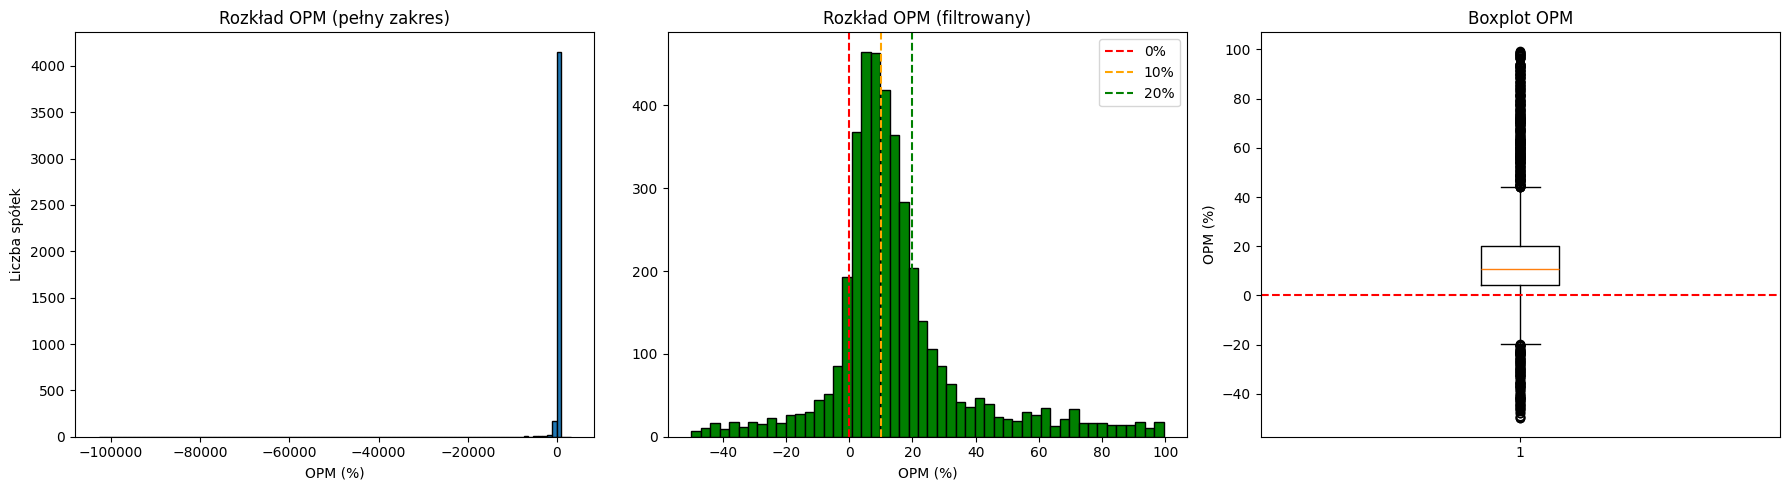

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram - pełny zakres
axes[0].hist(df['OPM'].dropna(), bins=100, edgecolor='black')
axes[0].set_title('Rozkład OPM (pełny zakres)')
axes[0].set_xlabel('OPM (%)')
axes[0].set_ylabel('Liczba spółek')

# Histogram - filtrowany (-50% do 100%)
df_filtered = df[(df['OPM'] >= -50) & (df['OPM'] <= 100)]
axes[1].hist(df_filtered['OPM'], bins=50, color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', label='0%')
axes[1].axvline(x=10, color='orange', linestyle='--', label='10%')
axes[1].axvline(x=20, color='green', linestyle='--', label='20%')
axes[1].set_title('Rozkład OPM (filtrowany)')
axes[1].set_xlabel('OPM (%)')
axes[1].legend()

# Boxplot
axes[2].boxplot(df_filtered['OPM'].dropna())
axes[2].set_title('Boxplot OPM')
axes[2].set_ylabel('OPM (%)')
axes[2].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('opm_distribution.png', dpi=300)
plt.show()

In [3]:
# Krok 1: Usunięcie oczywistych błędów
df_clean = df[(df['OPM'] > -100) & (df['OPM'] < 200)].copy()
print(f"Usunięto {len(df) - len(df_clean)} rekordów z ekstremalnymi wartościami")

# Krok 2: Winsoryzacja (capping na percentylach)
lower = df_clean['OPM'].quantile(0.01)
upper = df_clean['OPM'].quantile(0.99)
df_clean['OPM_clean'] = df_clean['OPM'].clip(lower, upper)

# Krok 3: Caps biznesowe
df_clean['OPM_clean'] = df_clean['OPM_clean'].clip(-50, 100)

print(f"OPM po czyszczeniu: mean={df_clean['OPM_clean'].mean():.2f}%, "
      f"median={df_clean['OPM_clean'].median():.2f}%")

Usunięto 501 rekordów z ekstremalnymi wartościami
OPM po czyszczeniu: mean=13.96%, median=10.54%


In [4]:
df_clean['opm_category'] = pd.cut(
    df_clean['OPM_clean'],
    bins=[-np.inf, 0, 10, 20, np.inf],
    labels=[0, 1, 2, 3]
)

In [5]:
import numpy as np
import pandas as pd

# ============================================================================
# FEATURE ENGINEERING (with outlier handling)
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

created_features = []

# ============================================================================
# 1. COST STRUCTURE RATIOS (4 features)
# ============================================================================
print("\n1️⃣ Cost Structure Ratios")

# Material cost ratio
df_clean['material_cost_ratio'] = (
    df_clean['Material cost last year'] / 
    df_clean['Sales last year'].replace(0, np.nan) * 100
)

# Winsorize (handle extreme outliers)
lower_mat = df_clean['material_cost_ratio'].quantile(0.01)
upper_mat = df_clean['material_cost_ratio'].quantile(0.99)
df_clean['material_cost_ratio'] = df_clean['material_cost_ratio'].clip(
    lower_mat, upper_mat
).clip(-10, 150)  # Business rule: max 150% of sales

created_features.append('material_cost_ratio')
print(f"   ✅ material_cost_ratio (mean: {df_clean['material_cost_ratio'].mean():.1f}%)")

# Employee cost ratio
df_clean['employee_cost_ratio'] = (
    df_clean['Employee cost last year'] / 
    df_clean['Sales last year'].replace(0, np.nan) * 100
)

# Winsorize
lower_emp = df_clean['employee_cost_ratio'].quantile(0.01)
upper_emp = df_clean['employee_cost_ratio'].quantile(0.99)
df_clean['employee_cost_ratio'] = df_clean['employee_cost_ratio'].clip(
    lower_emp, upper_emp
).clip(-10, 150)

created_features.append('employee_cost_ratio')
print(f"   ✅ employee_cost_ratio (mean: {df_clean['employee_cost_ratio'].mean():.1f}%)")

# Total cost ratio
df_clean['total_cost_ratio'] = (
    df_clean['material_cost_ratio'] + df_clean['employee_cost_ratio']
)

created_features.append('total_cost_ratio')
print(f"   ✅ total_cost_ratio (mean: {df_clean['total_cost_ratio'].mean():.1f}%)")

# Depreciation ratio
df_clean['depreciation_ratio'] = (
    df_clean['Depreciation'] / 
    df_clean['Sales'].replace(0, np.nan) * 100
)

# Winsorize
lower_dep = df_clean['depreciation_ratio'].quantile(0.01)
upper_dep = df_clean['depreciation_ratio'].quantile(0.99)
df_clean['depreciation_ratio'] = df_clean['depreciation_ratio'].clip(
    lower_dep, upper_dep
).clip(-5, 50)  # Max 50% depreciation

created_features.append('depreciation_ratio')
print(f"   ✅ depreciation_ratio (mean: {df_clean['depreciation_ratio'].mean():.1f}%)")

# ============================================================================
# 2. GROWTH & MOMENTUM (3 features)
# ============================================================================
print("\n2️⃣ Growth & Momentum")

# Sales growth
df_clean['sales_growth'] = (
    (df_clean['Sales'] - df_clean['Sales last year']) / 
    df_clean['Sales last year'].replace(0, np.nan) * 100
)

# Winsorize (extreme growth/decline can be outliers)
df_clean['sales_growth'] = df_clean['sales_growth'].clip(
    df_clean['sales_growth'].quantile(0.01),
    df_clean['sales_growth'].quantile(0.99)
).clip(-90, 500)  # -90% decline to +500% growth

created_features.append('sales_growth')
print(f"   ✅ sales_growth (mean: {df_clean['sales_growth'].mean():.1f}%)")

# OPM change
df_clean['opm_change'] = (
    df_clean['OPM_clean'] - df_clean['OPM last year']
)

# Winsorize
df_clean['opm_change'] = df_clean['opm_change'].clip(
    df_clean['opm_change'].quantile(0.01),
    df_clean['opm_change'].quantile(0.99)
)

created_features.append('opm_change')
print(f"   ✅ opm_change (mean: {df_clean['opm_change'].mean():.1f}%)")

# Improving OPM (binary)
df_clean['improving_opm'] = (df_clean['opm_change'] > 0).astype(int)

created_features.append('improving_opm')
print(f"   ✅ improving_opm ({df_clean['improving_opm'].sum()} improving)")

# ============================================================================
# 3. COMPANY SIZE (2 features)
# ============================================================================
print("\n3️⃣ Company Size (log transformation)")

# Log sales
df_clean['log_sales'] = np.log1p(df_clean['Sales'].clip(lower=0))

created_features.append('log_sales')
print(f"   ✅ log_sales (mean: {df_clean['log_sales'].mean():.2f})")

# Log market cap
df_clean['log_market_cap'] = np.log1p(
    df_clean['Market Capitalization'].clip(lower=0)
)

created_features.append('log_market_cap')
print(f"   ✅ log_market_cap (mean: {df_clean['log_market_cap'].mean():.2f})")

# ============================================================================
# 4. BINARY INDICATORS (2 features)
# ============================================================================
print("\n4️⃣ Binary Indicators")

# Profitable last year
df_clean['profitable_last_year'] = (
    df_clean['Profit after tax last year'] > 0
).astype(int)

created_features.append('profitable_last_year')
print(f"   ✅ profitable_last_year ({df_clean['profitable_last_year'].sum()} profitable)")

# Positive OPM last year
df_clean['positive_opm_last_year'] = (
    df_clean['OPM last year'] > 0
).astype(int)

created_features.append('positive_opm_last_year')
print(f"   ✅ positive_opm_last_year ({df_clean['positive_opm_last_year'].sum()} positive)")

# ============================================================================
# 5. EFFICIENCY (1 feature)
# ============================================================================
print("\n5️⃣ Efficiency Metrics")

# Asset turnover
df_clean['asset_turnover'] = (
    df_clean['Sales'] / 
    df_clean['Market Capitalization'].replace(0, np.nan)
)

# Winsorize
df_clean['asset_turnover'] = df_clean['asset_turnover'].clip(
    df_clean['asset_turnover'].quantile(0.01),
    df_clean['asset_turnover'].quantile(0.99)
)

created_features.append('asset_turnover')
print(f"   ✅ asset_turnover (mean: {df_clean['asset_turnover'].mean():.2f})")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

print(f"\n📊 Created {len(created_features)} new features:")
for i, feat in enumerate(created_features, 1):
    print(f"   {i:2}. {feat}")

print(f"\n✅ All features created successfully!")

# Verify no infinities
inf_counts = df_clean[created_features].apply(lambda x: np.isinf(x).sum())
if inf_counts.sum() > 0:
    print(f"\n⚠️  Found infinities - replacing with NaN:")
    for feat, count in inf_counts[inf_counts > 0].items():
        print(f"   {feat}: {count} infinities")
    df_clean[created_features] = df_clean[created_features].replace([np.inf, -np.inf], np.nan)
    print(f"   ✅ Replaced infinities with NaN")

print(f"\n📈 Feature statistics:")
stats = df_clean[created_features].describe().T[['mean', 'std', 'min', 'max']]
print(stats.round(2).to_string())


FEATURE ENGINEERING

1️⃣ Cost Structure Ratios
   ✅ material_cost_ratio (mean: 43.9%)
   ✅ employee_cost_ratio (mean: 13.1%)
   ✅ total_cost_ratio (mean: 57.0%)
   ✅ depreciation_ratio (mean: 3.8%)

2️⃣ Growth & Momentum
   ✅ sales_growth (mean: 0.0%)
   ✅ opm_change (mean: 0.1%)
   ✅ improving_opm (97 improving)

3️⃣ Company Size (log transformation)
   ✅ log_sales (mean: 5.14)
   ✅ log_market_cap (mean: 5.95)

4️⃣ Binary Indicators
   ✅ profitable_last_year (3508 profitable)
   ✅ positive_opm_last_year (3585 positive)

5️⃣ Efficiency Metrics
   ✅ asset_turnover (mean: 0.95)

FEATURE ENGINEERING SUMMARY

📊 Created 12 new features:
    1. material_cost_ratio
    2. employee_cost_ratio
    3. total_cost_ratio
    4. depreciation_ratio
    5. sales_growth
    6. opm_change
    7. improving_opm
    8. log_sales
    9. log_market_cap
   10. profitable_last_year
   11. positive_opm_last_year
   12. asset_turnover

✅ All features created successfully!

📈 Feature statistics:
                

In [6]:
df_clean = df_clean[df_clean['opm_category'].notna()]

In [7]:
print(df_clean['opm_category'].describe())
print(df_clean['OPM_clean'].describe())

count     4167
unique       4
top          1
freq      1410
Name: opm_category, dtype: int64
count    4167.000000
mean       13.956110
std        23.599041
min       -50.000000
25%         3.835000
50%        10.540000
75%        19.905000
max        92.624800
Name: OPM_clean, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Załóżmy że masz df_raw i df_clean
# df_raw = pd.read_csv('data/Annual_P_L_1_final.csv')
# df_clean = ... (po preprocessingu)

# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

fig = plt.figure(figsize=(20, 12))

# ============================================================================
# WYKRES 1: OPM - Przed vs Po czyszczeniu
# ============================================================================
ax1 = plt.subplot(2, 3, 1)

# Before cleaning (filtered dla widoczności)
df_raw_filtered = df_raw[(df_raw['OPM'] > -200) & (df_raw['OPM'] < 200)]
ax1.hist(df_raw_filtered['OPM'].dropna(), bins=100, 
         alpha=0.7, color='red', edgecolor='black', label='Przed czyszczeniem')
ax1.axvline(df_raw['OPM'].mean(), color='darkred', linestyle='--', 
           linewidth=2, label=f'Średnia: {df_raw["OPM"].mean():.1f}%')
ax1.axvline(df_raw['OPM'].median(), color='red', linestyle='-', 
           linewidth=2, label=f'Mediana: {df_raw["OPM"].median():.1f}%')
ax1.set_xlabel('OPM (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Liczba spółek', fontsize=11, fontweight='bold')
ax1.set_title('(A) OPM przed czyszczeniem\n(ekstremalne outliers)', 
             fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlim(-200, 200)

# After cleaning
ax2 = plt.subplot(2, 3, 2)
ax2.hist(df_clean['OPM_clean'].dropna(), bins=50, 
         alpha=0.7, color='green', edgecolor='black', label='Po czyszczeniu')
ax2.axvline(df_clean['OPM_clean'].mean(), color='darkgreen', linestyle='--', 
           linewidth=2, label=f'Średnia: {df_clean["OPM_clean"].mean():.1f}%')
ax2.axvline(df_clean['OPM_clean'].median(), color='green', linestyle='-', 
           linewidth=2, label=f'Mediana: {df_clean["OPM_clean"].median():.1f}%')
ax2.axvline(0, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label='0%')
ax2.axvline(10, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='10%')
ax2.axvline(20, color='blue', linestyle=':', linewidth=1.5, alpha=0.7, label='20%')
ax2.set_xlabel('OPM (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Liczba spółek', fontsize=11, fontweight='bold')
ax2.set_title('(B) OPM po czyszczeniu\n(caps: -50% do 93%)', 
             fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ============================================================================
# WYKRES 2: Rozkład kategorii OPM
# ============================================================================
ax3 = plt.subplot(2, 3, 3)

category_counts = df_clean['opm_category'].value_counts().sort_index()
category_labels = ['Negative\n(<0%)', 'Low\n(0-10%)', 'Medium\n(10-20%)', 'High\n(≥20%)']
colors = ['red', 'orange', 'lightgreen', 'green']

bars = ax3.bar(range(len(category_counts)), category_counts.values, 
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

ax3.set_xticks(range(len(category_counts)))
ax3.set_xticklabels(category_labels, fontsize=10, fontweight='bold')
ax3.set_ylabel('Liczba spółek', fontsize=11, fontweight='bold')
ax3.set_title('(C) Rozkład kategorii OPM\n(zmienna docelowa)', 
             fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add value labels and percentages
for bar, count in zip(bars, category_counts.values):
    height = bar.get_height()
    pct = count / category_counts.sum() * 100
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# ============================================================================
# WYKRES 3: Paradoks Simpsona - Analiza kwartylowa
# ============================================================================
ax4 = plt.subplot(2, 3, 4)

# Quartile analysis
df_analysis = df_clean[['total_cost_ratio', 'OPM_clean']].dropna()
df_analysis['cost_quartile'] = pd.qcut(df_analysis['total_cost_ratio'], 
                                        q=4, 
                                        labels=['Q1\n(Najniższe\nkoszty)', 
                                               'Q2', 'Q3', 
                                               'Q4\n(Najwyższe\nkoszty)'],
                                        duplicates='drop')

quartile_means = df_analysis.groupby('cost_quartile')['OPM_clean'].mean()
quartile_stds = df_analysis.groupby('cost_quartile')['OPM_clean'].std()

bars = ax4.bar(range(len(quartile_means)), quartile_means.values,
              color=['darkgreen', 'lightgreen', 'orange', 'red'],
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Error bars
ax4.errorbar(range(len(quartile_means)), quartile_means.values,
            yerr=quartile_stds.values, fmt='none', color='black',
            capsize=5, linewidth=2, alpha=0.6)

ax4.set_xticks(range(len(quartile_means)))
ax4.set_xticklabels(quartile_means.index, fontsize=10, fontweight='bold')
ax4.set_ylabel('Średnie OPM (%)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Kwartyl kosztów operacyjnych', fontsize=11, fontweight='bold')
ax4.set_title('(D) Analiza kwartylowa\ntotal_cost_ratio vs OPM', 
             fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, quartile_means.values):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

# Add significance arrow
diff = quartile_means.iloc[0] - quartile_means.iloc[-1]
ax4.plot([0, 3], [quartile_means.iloc[0], quartile_means.iloc[0]],
        'k--', alpha=0.3, linewidth=1)
ax4.annotate('', xy=(3.3, quartile_means.iloc[3]),
            xytext=(3.3, quartile_means.iloc[0]),
            arrowprops=dict(arrowstyle='<->', lw=2.5, color='black'))
ax4.text(3.6, (quartile_means.iloc[0] + quartile_means.iloc[3])/2,
        f'Δ={diff:.1f}%\n(p<0.001)', fontsize=11, fontweight='bold',
        va='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# ============================================================================
# WYKRES 4: Top branże - OPM vs koszty
# ============================================================================
ax5 = plt.subplot(2, 3, 5)

# Top 6 industries by count
top_industries = df_clean['Industry'].value_counts().head(6).index
industry_data = df_clean[df_clean['Industry'].isin(top_industries)].groupby('Industry').agg({
    'total_cost_ratio': 'mean',
    'OPM_clean': 'mean',
    'Industry': 'count'
}).rename(columns={'Industry': 'count'})

# Sort by OPM descending
industry_data = industry_data.sort_values('OPM_clean', ascending=True)

# Shorten names
industry_labels = [name[:30] for name in industry_data.index]

# Color by OPM level
colors_ind = ['darkgreen' if opm > 20 else 'lightgreen' if opm > 10 else 'orange' if opm > 5 else 'red'
             for opm in industry_data['OPM_clean']]

# Horizontal bar chart
bars = ax5.barh(range(len(industry_data)), industry_data['OPM_clean'].values,
               color=colors_ind, edgecolor='black', linewidth=1.5, alpha=0.8)

ax5.set_yticks(range(len(industry_data)))
ax5.set_yticklabels(industry_labels, fontsize=9)
ax5.set_xlabel('Średnie OPM (%)', fontsize=11, fontweight='bold')
ax5.set_title('(E) Top 6 branż według OPM\n(rozkład branżowy)', 
             fontsize=12, fontweight='bold')
ax5.grid(axis='x', alpha=0.3)

# Add value labels with cost ratio
for i, (bar, opm, cost) in enumerate(zip(bars, 
                                          industry_data['OPM_clean'].values,
                                          industry_data['total_cost_ratio'].values)):
    ax5.text(opm + 1, bar.get_y() + bar.get_height()/2,
            f'{opm:.1f}%\n(koszty: {cost:.0f}%)',
            va='center', fontsize=9, fontweight='bold')

# ============================================================================
# WYKRES 5: Statystyki opisowe - tabela
# ============================================================================
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Statistics comparison table
stats_data = [
    ['Metryka', 'Przed', 'Po', 'Zmiana'],
    ['', '', '', ''],
    ['Liczba próbek', f'{len(df_raw):,}', f'{len(df_clean):,}', 
     f'{len(df_raw)-len(df_clean):,} ({(len(df_raw)-len(df_clean))/len(df_raw)*100:.1f}%)'],
    ['Średnia OPM', f'{df_raw["OPM"].mean():.1f}%', f'{df_clean["OPM_clean"].mean():.1f}%',
     f'{df_clean["OPM_clean"].mean() - df_raw["OPM"].mean():+.1f}%'],
    ['Mediana OPM', f'{df_raw["OPM"].median():.1f}%', f'{df_clean["OPM_clean"].median():.1f}%',
     f'{df_clean["OPM_clean"].median() - df_raw["OPM"].median():+.1f}%'],
    ['Odch. std.', f'{df_raw["OPM"].std():.1f}%', f'{df_clean["OPM_clean"].std():.1f}%',
     f'{df_clean["OPM_clean"].std() - df_raw["OPM"].std():+.1f}%'],
    ['Minimum', f'{df_raw["OPM"].min():.0f}%', f'{df_clean["OPM_clean"].min():.1f}%',
     f'{df_clean["OPM_clean"].min() - df_raw["OPM"].min():+.0f}%'],
    ['Maksimum', f'{df_raw["OPM"].max():.0f}%', f'{df_clean["OPM_clean"].max():.1f}%',
     f'{df_clean["OPM_clean"].max() - df_raw["OPM"].max():+.0f}%'],
    ['', '', '', ''],
    ['Mean-Median gap', 
     f'{abs(df_raw["OPM"].mean() - df_raw["OPM"].median()):.1f}%',
     f'{abs(df_clean["OPM_clean"].mean() - df_clean["OPM_clean"].median()):.1f}%',
     '✅ Zmniejszone!'],
]

table = ax6.table(cellText=stats_data, cellLoc='center', loc='center',
                 colWidths=[0.35, 0.22, 0.22, 0.21])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Style separator rows
table[(1, 0)].set_facecolor('#e0e0e0')
table[(8, 0)].set_facecolor('#e0e0e0')

# Alternate row colors
for i in range(2, 8):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f5f5f5')

# Highlight last row
for j in range(4):
    table[(9, j)].set_facecolor('#fff9c4')
    table[(9, j)].set_text_props(weight='bold')

ax6.set_title('(F) Porównanie statystyk\nprzed i po preprocessingu',
             fontsize=12, fontweight='bold', pad=20)

# ============================================================================
# Overall title and save
# ============================================================================
fig.suptitle('Przygotowanie danych - Kluczowe etapy preprocessingu',
            fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('output/opm_classification/preprocessing_overview.png',
           dpi=300, bbox_inches='tight')
print("✅ Saved: preprocessing_overview.png")
plt.show()

# ============================================================================
# Print summary
# ============================================================================
print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)
print(f"\nPrzed czyszczeniem:")
print(f"  Próbki: {len(df_raw):,}")
print(f"  OPM mean: {df_raw['OPM'].mean():.2f}%")
print(f"  OPM median: {df_raw['OPM'].median():.2f}%")
print(f"  OPM zakres: {df_raw['OPM'].min():.0f}% do {df_raw['OPM'].max():.0f}%")

print(f"\nPo czyszczeniu:")
print(f"  Próbki: {len(df_clean):,} (utrata: {len(df_raw)-len(df_clean)} = {(len(df_raw)-len(df_clean))/len(df_raw)*100:.1f}%)")
print(f"  OPM mean: {df_clean['OPM_clean'].mean():.2f}%")
print(f"  OPM median: {df_clean['OPM_clean'].median():.2f}%")
print(f"  OPM zakres: {df_clean['OPM_clean'].min():.1f}% do {df_clean['OPM_clean'].max():.1f}%")

print(f"\n✅ Mean-Median gap zmniejszony z {abs(df_raw['OPM'].mean() - df_raw['OPM'].median()):.1f}% do {abs(df_clean['OPM_clean'].mean() - df_clean['OPM_clean'].median()):.1f}%")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed data
df = pd.read_csv('output/opm_classification/data_cleaned_with_features.csv')

# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# Select features for correlation
features_for_corr = [
    # Target
    'OPM_clean',
    
    # Historical
    'OPM last year',
    'Profit after tax last year',
    'Sales last year',
    'positive_opm_last_year',
    'profitable_last_year',
    
    # Cost structure
    'material_cost_ratio',
    'employee_cost_ratio',
    'total_cost_ratio',
    'depreciation_ratio',
    
    # Growth
    'sales_growth',
    'opm_change',
    'improving_opm',
    
    # Size
    'log_sales',
    'log_market_cap',
    
    # Efficiency
    'Return on capital employed',
    'asset_turnover',
    
    # Financial
    'Interest',
    'Depreciation',
]

# Filter available
available = [f for f in features_for_corr if f in df.columns]
df_corr = df[available].copy()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Extract correlations with OPM_clean
opm_corr = corr_matrix['OPM_clean'].drop('OPM_clean').sort_values(key=abs, ascending=False)

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ============================================================================
# PANEL A: Bar plot - Correlations with OPM
# ============================================================================
ax1 = axes[0]

colors = ['darkgreen' if x > 0 else 'darkred' for x in opm_corr.values]
bars = ax1.barh(range(len(opm_corr)), opm_corr.values, color=colors, alpha=0.7, edgecolor='black')

ax1.set_yticks(range(len(opm_corr)))
ax1.set_yticklabels(opm_corr.index, fontsize=10)
ax1.set_xlabel('Korelacja Pearsona z OPM', fontsize=12, fontweight='bold')
ax1.set_title('(A) Korelacje indywidualne features z OPM\n(poziom liniowy)', 
             fontsize=13, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, opm_corr.values)):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            ha=ha, va='center', fontsize=9, fontweight='bold')

# Highlight zones
ax1.text(0.7, len(opm_corr)-1, 'Silna\npozytywna', fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax1.text(-0.7, len(opm_corr)-1, 'Silna\nnegatywna', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# ============================================================================
# PANEL B: Key statistics comparison
# ============================================================================
ax2 = axes[1]
ax2.axis('off')

# Create comparison table
stats_data = [
    ['Feature', 'r', 'Interpretacja', 'Status'],
    ['', '', '', ''],
    ['OPM last year', f'{opm_corr["OPM last year"]:.3f}', 'Momentum/persistence', '⭐⭐⭐⭐⭐'],
    ['positive_opm_last_year', f'{opm_corr["positive_opm_last_year"]:.3f}', 'Binary indicator', '⭐⭐⭐⭐'],
    ['profitable_last_year', f'{opm_corr["profitable_last_year"]:.3f}', 'Profitability flag', '⭐⭐⭐'],
    ['total_cost_ratio', f'{opm_corr["total_cost_ratio"]:.3f}', 'Direct component', '⭐⭐'],
    ['material_cost_ratio', f'{opm_corr["material_cost_ratio"]:.3f}', 'Cost structure', '⭐⭐'],
    ['employee_cost_ratio', f'{opm_corr["employee_cost_ratio"]:.3f}', 'Labor costs', '⭐'],
    ['log_market_cap', f'{opm_corr["log_market_cap"]:.3f}', 'Company size', '⭐'],
    ['', '', '', ''],
    ['WAŻNE:', '', 'Słaba korelacja ≠ Słaby feature!', ''],
    ['', '', 'Analiza kwartylowa:', ''],
    ['', '', 'Q1→Q4: Δ = 22.5% (p<0.001)', '✅'],
    ['', '', 'Industry level: r = -0.85', '✅'],
]

table = ax2.table(cellText=stats_data, cellLoc='left', loc='center',
                 colWidths=[0.35, 0.15, 0.35, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#2196F3')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Style separator rows
table[(1, 0)].set_facecolor('#e0e0e0')
table[(9, 0)].set_facecolor('#e0e0e0')

# Alternate row colors
for i in range(2, 9):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f5f5f5')

# Highlight bottom rows (key message)
for i in range(10, 14):
    for j in range(4):
        table[(i, j)].set_facecolor('#fff9c4')
        if i == 10:
            table[(i, j)].set_text_props(weight='bold', color='red', fontsize=11)

ax2.set_title('(B) Top korelacje i kluczowe ustalenia\n(kontekst interpretacji)',
             fontsize=13, fontweight='bold', pad=20)

# ============================================================================
# Overall title and save
# ============================================================================
fig.suptitle('Analiza korelacji features z OPM - Poziom indywidualny vs grupowy',
            fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('output/opm_classification/correlation_analysis.png',
           dpi=300, bbox_inches='tight')
print("✅ Saved: correlation_analysis.png")
plt.show()

# ============================================================================
# Print summary
# ============================================================================
print("\n" + "="*80)
print("CORRELATION SUMMARY")
print("="*80)

print(f"\n📊 Top 5 pozytywnych korelacji:")
top_pos = opm_corr[opm_corr > 0].head(5)
for feat, val in top_pos.items():
    print(f"   {feat:35} r = {val:+.3f}")

print(f"\n📊 Top 5 negatywnych korelacji:")
top_neg = opm_corr[opm_corr < 0].head(5)
for feat, val in top_neg.items():
    print(f"   {feat:35} r = {val:+.3f}")

print(f"\n💡 Kluczowe obserwacje:")
print(f"   ✅ OPM last year dominuje (r={opm_corr['OPM last year']:.3f})")
print(f"   ⚠️  Cost ratios słabe (r={opm_corr['total_cost_ratio']:.3f})")
print(f"   ✅ Ale: Quartile effect = 22.5% (silny!)")
print(f"   ✅ Industry level = -0.85 (bardzo silny!)")